# Bengaluru NGO Student Engagement & Risk Analytics

This project analyzes 500 student records across Bengaluru NGO education programs to evaluate attendance patterns, score improvement, program effectiveness, and student risk segmentation.

The objective is to identify high-risk student groups, compare program outcomes, and support data-driven intervention and resource allocation strategies.

## 1. Project Setup

This section extracts the project files and prepares the working directory for analysis.

In [1]:
import zipfile
import os

zip_path = "/content/ngo_education_analytics_project_package_with_code.zip"
extract_path = "/content/ngo_education_analytics_project"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")
print(os.listdir(extract_path))

Extracted successfully!
['clean_performance.csv', 'NGO_Education_Analytics_Bengaluru_2021_2022.ipynb', 'clean_homework.csv', 'center_cost_data.csv', 'clean_students.csv', 'program_participation.csv', 'clean_attendance.csv', 'README_project_notes.txt', 'clean_bengaluru_school_context.csv', 'NGO_Project_Next_Steps_and_Presentation_Guide.md', 'data_dictionary.csv', 'clean_parent_communication.csv', 'project_build_summary.csv', 'build_ngo_project.py', 'ngo_student_master_2021_2022.csv']


## 2. Data Loading

The master dataset contains 500 student-level records with demographic, attendance, program, performance, and risk-related fields.

In [2]:
import pandas as pd

PROJECT_DIR = "/content/ngo_education_analytics_project"

master = pd.read_csv(f"{PROJECT_DIR}/ngo_student_master_2021_2022.csv")

print("Master dataset shape:", master.shape)
master.head()

Master dataset shape: (500, 39)


,student_id,student_name,date_of_birth,age_as_of_aug2021,gender,grade_level,school_type,center_id,region,digital_access,...,teacher_to_parent_count,automated_reminder_count,monthly_cost_per_student_inr,capacity_utilization,engagement_score,engagement_level,dropout_flag,risk_category,improved_student_flag,cost_per_improved_student_inr
0,S00008,James Wheeler,2011-01-25,10.5,Female,Grade 1,Aided,BLR-C04,Hebbal,Good,...,1,0,1533,0.848,53.2,Medium,0,Medium Risk,1,1981.0
1,S00022,Justin Wright,2010-06-25,11.1,Male,Grade 2,Government,BLR-C03,Yelahanka,Limited,...,1,0,2076,0.937,53.0,Medium,0,Medium Risk,0,2678.0
2,S00041,Robert Walters,2017-03-28,4.3,Male,Grade 1,Government,BLR-C01,Whitefield,Limited,...,2,0,1885,0.833,43.2,Medium,1,High Risk,0,2792.0
3,S00043,Amanda Davis,2008-01-17,13.5,Female,Grade 2,Aided,BLR-C01,Whitefield,Limited,...,3,0,1885,0.833,53.1,Medium,0,Medium Risk,0,2792.0
4,S00045,Melanie Martinez,NaN,NaN,Male,Grade 5,Government,BLR-C03,Yelahanka,Good,...,0,1,2076,0.937,74.1,High,0,Medium Risk,1,2678.0


## 3. Data Quality Check

This section reviews dataset size, duplicate student records, and missing values to validate the quality of the master dataset before analysis.

In [2]:
clean_students = pd.read_csv(f"{PROJECT_DIR}/clean_students.csv")
clean_attendance = pd.read_csv(f"{PROJECT_DIR}/clean_attendance.csv")
clean_homework = pd.read_csv(f"{PROJECT_DIR}/clean_homework.csv")
clean_performance = pd.read_csv(f"{PROJECT_DIR}/clean_performance.csv")
clean_parent_comm = pd.read_csv(f"{PROJECT_DIR}/clean_parent_communication.csv")
school_context = pd.read_csv(f"{PROJECT_DIR}/clean_bengaluru_school_context.csv")
program_participation = pd.read_csv(f"{PROJECT_DIR}/program_participation.csv")
center_cost = pd.read_csv(f"{PROJECT_DIR}/center_cost_data.csv")

print("Students:", clean_students.shape)
print("Attendance:", clean_attendance.shape)
print("Homework:", clean_homework.shape)
print("Performance:", clean_performance.shape)
print("Parent communication:", clean_parent_comm.shape)
print("School context:", school_context.shape)
print("Program participation:", program_participation.shape)
print("Center cost:", center_cost.shape)


NameError: name 'pd' is not defined

## 4. KPI Summary

The following KPIs summarize student engagement, academic improvement, and risk concentration across the project cohort.

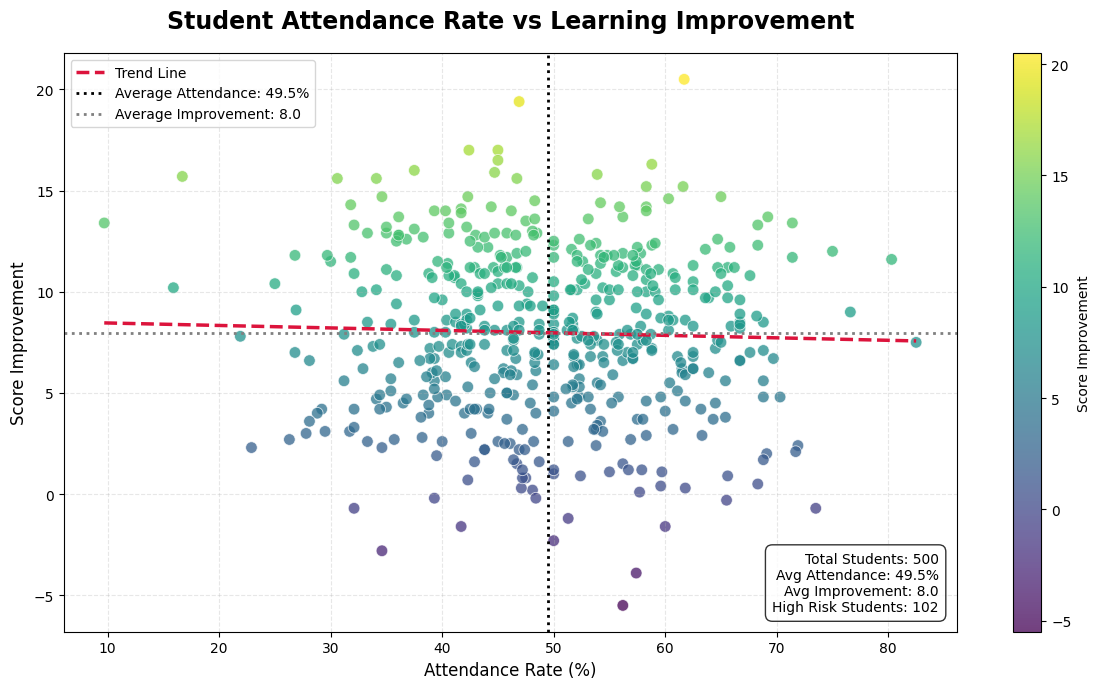

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Convert attendance to percentage
x = master["attendance_rate"] * 100
y = master["score_improvement"]

# Create trend line
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)
x_sorted = np.sort(x)

# Create polished chart
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    x,
    y,
    s=70,
    alpha=0.75,
    c=y,
    cmap="viridis",
    edgecolors="white",
    linewidth=0.6
)

ax.plot(
    x_sorted,
    trend(x_sorted),
    linestyle="--",
    linewidth=2.5,
    color="crimson",
    label="Trend Line"
)

ax.axvline(
    x.mean(),
    linestyle=":",
    linewidth=2,
    color="black",
    label=f"Average Attendance: {x.mean():.1f}%"
)

ax.axhline(
    y.mean(),
    linestyle=":",
    linewidth=2,
    color="gray",
    label=f"Average Improvement: {y.mean():.1f}"
)

ax.set_title(
    "Student Attendance Rate vs Learning Improvement",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Attendance Rate (%)", fontsize=12)
ax.set_ylabel("Score Improvement", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label("Score Improvement")

insight_text = (
    f"Total Students: {master['student_id'].nunique()}\n"
    f"Avg Attendance: {x.mean():.1f}%\n"
    f"Avg Improvement: {y.mean():.1f}\n"
    f"High Risk Students: {(master['risk_category'] == 'High Risk').sum()}"
)

ax.text(
    0.98,
    0.03,
    insight_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="bottom",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8)
)

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Interactive Dashboard

The cleaned and analyzed dataset was used to build an interactive Looker Studio dashboard.

Dashboard Link: https://datastudio.google.com/embed/u/0/reporting/2a7b3eb3-4d48-4e47-a619-fc1b0a3a5c7c/page/p_qvnptwhc4d

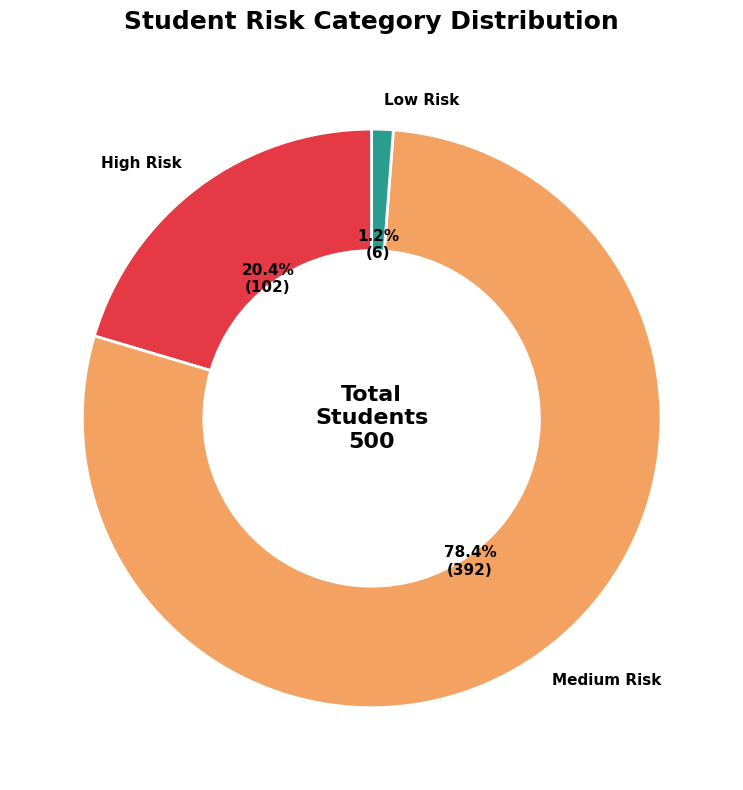

In [12]:
import matplotlib.pyplot as plt

# Reorder categories nicely
risk_order = ["High Risk", "Medium Risk", "Low Risk"]
risk_counts = master["risk_category"].value_counts().reindex(risk_order, fill_value=0)

colors = ["#e63946", "#f4a261", "#2a9d8f"]  # red, orange, green

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100 * risk_counts.sum()))})",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    textprops=dict(color="black", fontsize=11, fontweight="bold")
)

# Center text
ax.text(
    0, 0,
    f"Total\nStudents\n{risk_counts.sum()}",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "Student Risk Category Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

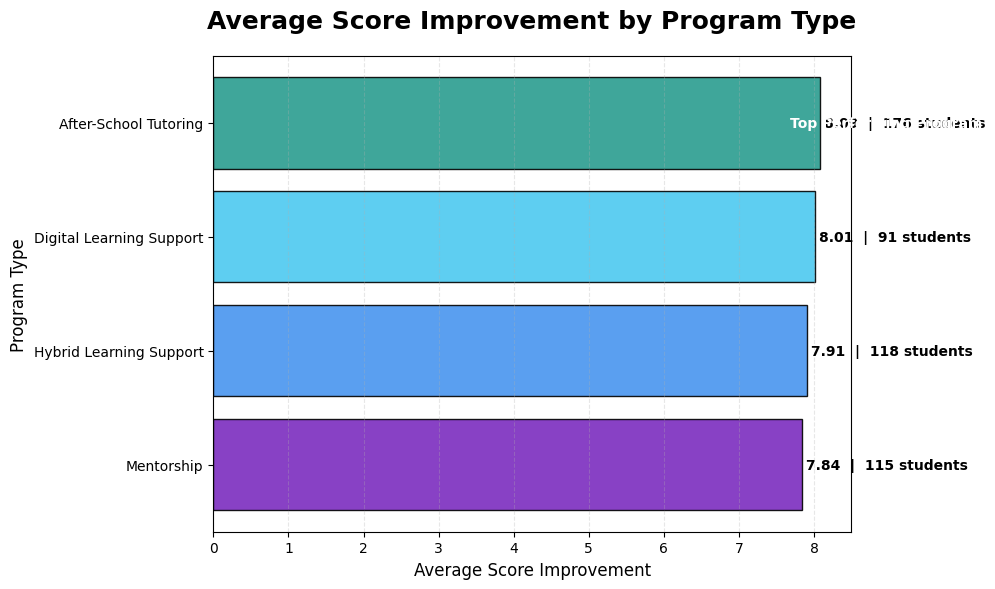

In [13]:
import matplotlib.pyplot as plt

program_summary = master.groupby("program_type").agg(
    avg_score_improvement=("score_improvement", "mean"),
    students=("student_id", "nunique")
).reset_index()

program_summary = program_summary.sort_values("avg_score_improvement", ascending=True)

colors = ["#7b2cbf", "#4895ef", "#4cc9f0", "#2a9d8f"]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    program_summary["program_type"],
    program_summary["avg_score_improvement"],
    color=colors,
    edgecolor="black",
    alpha=0.9
)

# Add labels on bars
for bar, value, students in zip(
    bars,
    program_summary["avg_score_improvement"],
    program_summary["students"]
):
    ax.text(
        value + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}  |  {students} students",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Average Score Improvement by Program Type",
    fontsize=18,
    fontweight="bold",
    pad=20
)
ax.set_xlabel("Average Score Improvement", fontsize=12)
ax.set_ylabel("Program Type", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.3)

# Optional: highlight best program
best_program = program_summary.iloc[-1]
ax.text(
    best_program["avg_score_improvement"] - 0.4,
    len(program_summary)-1,
    "Top Performing Program",
    color="white",
    fontsize=10,
    fontweight="bold",
    va="center"
)

plt.tight_layout()
plt.show()

### Insight
Yelahanka, KR Puram, and Hebbal had the highest concentration of high-risk students. These regions should be prioritized for targeted academic support, mentor follow-ups, and parent communication. Instead of distributing resources equally across all centers, the NGO can use this dashboard to allocate volunteers and tutoring hours based on student risk concentration.


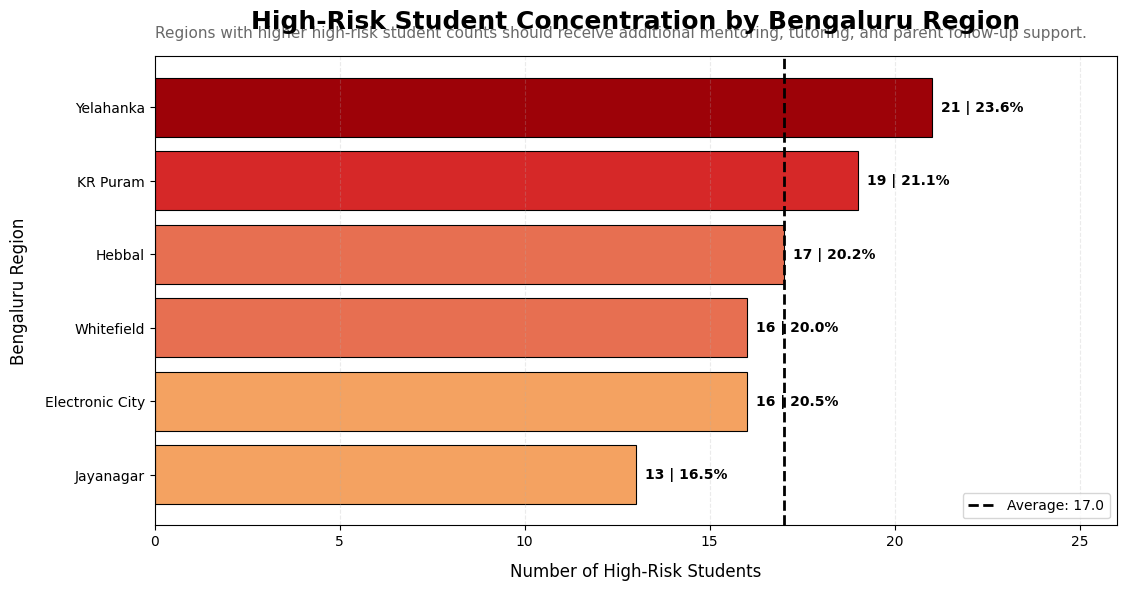

In [16]:
import matplotlib.pyplot as plt

center_summary = master.groupby("region").agg(
    students=("student_id", "nunique"),
    high_risk_students=("risk_category", lambda x: (x == "High Risk").sum()),
    avg_attendance_rate=("attendance_rate", "mean"),
    avg_score_improvement=("score_improvement", "mean")
).reset_index()

center_summary["high_risk_rate"] = (
    center_summary["high_risk_students"] / center_summary["students"] * 100
)

center_summary = center_summary.sort_values("high_risk_students", ascending=True)

colors = ["#f4a261", "#f4a261", "#e76f51", "#e76f51", "#d62828", "#9d0208"]

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    center_summary["region"],
    center_summary["high_risk_students"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

# Add labels inside/near bars
for bar, count, rate in zip(
    bars,
    center_summary["high_risk_students"],
    center_summary["high_risk_rate"]
):
    ax.text(
        count + 0.25,
        bar.get_y() + bar.get_height()/2,
        f"{count} | {rate:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

avg_high_risk = center_summary["high_risk_students"].mean()

ax.axvline(
    avg_high_risk,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Average: {avg_high_risk:.1f}"
)

ax.set_title(
    "High-Risk Student Concentration by Bengaluru Region",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.text(
    0,
    1.04,
    "Regions with higher high-risk student counts should receive additional mentoring, tutoring, and parent follow-up support.",
    transform=ax.transAxes,
    fontsize=11,
    color="dimgray"
)

ax.set_xlabel("Number of High-Risk Students", fontsize=12, labelpad=10)
ax.set_ylabel("Bengaluru Region", fontsize=12, labelpad=12)

ax.set_xlim(0, center_summary["high_risk_students"].max() + 5)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.legend(loc="lower right")

plt.subplots_adjust(left=0.18, right=0.92, top=0.82, bottom=0.15)
plt.show()

### Business Insight

Yelahanka, KR Puram, and Hebbal had the highest concentration of high-risk students. These regions should be prioritized for targeted academic support, mentor follow-ups, and parent communication. Instead of distributing resources equally across all centers, the NGO can allocate volunteers and tutoring hours based on student risk concentration.

**Recommended Action:** Create a weekly high-risk student watchlist for these regions and assign additional mentor follow-ups to students with low attendance or weak score improvement.

## Final Conclusion

This project showed how student-level education data can be used to support NGO decision-making. By combining attendance, performance, homework engagement, parent communication, and Bengaluru school context data, I created a student risk monitoring framework.

The analysis identified 102 high-risk students out of 500 and showed that certain Bengaluru regions had higher concentrations of student risk. The final recommendation was to use weekly risk monitoring, targeted mentor follow-ups, and center-level dashboards to improve retention and learning outcomes.